#### TOLIMAN Pupil Gluing Analysis: Preliminary Measurements

**Aim:**  
To determine:
1. The optical aberrations induced by the lab setup for pupil testing (consisting of 2 OAPs)
2. The intensity distribution ouput from the optical fiber output for later modelling

If we can show these aberrations are static over a long enough period of time (> 30min) then we can confidently remove them from the phase retrieval analysis of the later measurements (glued vs non-glued).

We have chosen to place a spider mask (necessary asymmetry) within the collimated beam to characterise these aberrations via phase retrieval (thank u differentiable modelling/dLux 💖)
________________________________________________________________________________________________
**NOTE (on data orientation)**: When modelling dLux layers (aberrated apertures, transmissive layers, etc) - they are orientated w.r.t wavefront POV in direction of propagation. In our setup, the data collected has two orientation flips:
1. BFS-U3-200S6M flips image upside down from propagation direction POV (and stores it like this too)
2. The pupil plane is focused by a second OAP which reflects propgagtion direction and in-turn flips left-right (and it stores it like this too)

i.e. total effect is that data is flipped about origin. <3
________________________________________________________________________________________________

In [1]:
import dLux as dl
import dLux.utils as dlu

import jax.numpy as jnp
import numpy as np

import jax.random as jr
import jax.scipy as jsp
from jax import vmap
import jax

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_debug_nans", False)
jax.config.update("jax_disable_jit", False)

import zodiax as zdx
import optax

# from tqdm.notebook import tqdm
from tqdm import tqdm

from skimage.io import imread
from skimage.filters import window
import skimage as ski
from skimage.transform import resize

import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm, CenteredNorm

from src.PhaseRetrieval import (
    OptimManager,
    JointOptimManager,
    PointSource,
    TransmissiveLayer,
    AngularOpticalSystem,
    PixelBasisTransmissiveLayer,
    BasisOptic,
)

import os
import pickle

from src.PhaseRetrieval import DynamicAperture
from src.uv import dummy_splodge_mask, compute_complex_vis, UVComponents
import matplotlib.colors as mcolors

import imageio

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = (
    "false"  # jax grab gpu only when necessary (helpful for big plots)
)

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "upper"
plt.rcParams["figure.dpi"] = 72
plt.rcParams["figure.figsize"] = (10, 10)
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["figure.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 15

# data_dir = "/home/dgxuser/grace/gpir9156/toliman/" # "/import/morgana2/gpir9156/toliman/"
# data_dir = "/import/morgana1/snert/gpir9156/toliman/"
# data_dir = "/import/morgana2/gpir9156/toliman/"


data_dir = "/Volumes/MORGANA2/gpir9156/toliman/"

In [2]:
print("Backend:", jax.default_backend())

Backend: cpu


In [3]:
# ------- Physical Parameters ---------------------------------------------------------------------#
aperture_npix = 256  # Number of pixels across the aperture
aperture_diameter = 126e-3  # for spider cap 126e-3    # (m) (spider cap CA =122mm, plain cap CA=124mm, open=126mm)
cap_diameter = 124e-3
sam18_diameter = 122e-3

spider_width = 20e-3  # Spider width (m)
spider_angle = (
    270  # Spider angle (degrees), clockwise, 0 is spider pointing vertically up
)
coords = dlu.pixel_coords(npixels=aperture_npix, diameter=aperture_diameter)
circle = dlu.circle(coords=coords, radius=aperture_diameter / 2)

# Observations wavelengths (bandpass of 530-640nm)
red_laser_wl = 635e-09  # for laser data
green_laser_wl = 520e-09  # for laser data
wf_npixels = aperture_npix  # Number of pixels across the wavefront
wf_diam = aperture_diameter  # Diameter of initial wavefront to propagate wavefront (m)

# Dtector parameters (BFS-U3-200S6-BD)
BFS_px_sep = 2.4e-6 * 1e3  # pixel separation (mm)
f_det = 1300  # 1350                    # Focal length from OAP2 to detector (mm)
px_ang_sep = 2 * np.arctan((BFS_px_sep / 2) / f_det)  # angular sep between pixels (rad)
BFS_rn = 3.27  # (e-)

# Simulated Detector
psf_npix = 40  # Number of pixels along one dim of the PSF
psf_hlf_sz = int(psf_npix / 2)
oversample = 1  # Oversampling factor for the PSF
psf_pixel_scale = dlu.rad2arcsec(
    px_ang_sep
)  # arcsec (to match detector plate scale) 80e-4

# Detector response (gamma curve) (flip about origin)
# det_data_dir = "/import/morgana2/gpir9156/toliman/detector"
# alpha = np.load(det_data_dir+"/500us_detector/ALPHA.npy")
# beta = np.load(det_data_dir+"/500us_detector/BETA.npy")
# gamma = np.load(det_data_dir+"/500us_detector/GAMMA.npy")

# det_data_dir = "/import/morgana1/snert/gpir9156/toliman/detector"
# alpha = np.load(det_data_dir+"/80us_detector/ALPHA_norm.npy")
# beta = np.load(det_data_dir+"/80us_detector/BETA_norm.npy")
# gamma = np.load(det_data_dir+"/80us_detector/GAMMA_norm.npy")

#### Load in some ✨real✨ data 🌈
- Check intensity distribution across pupil first


Trying dithering method (image too big to find a large/fast enough lens to fully re-image at detector so need to dither and combine two images)

NOTE only has to be run once to save joint img

Blur and re-size intensity image to create dLux transmission layer.  OR just have this as a prior for the center of a Gauss layer.

In [ ]:
# intensity_dist = imread("/import/morgana1/snert/gpir9156/toliman/intensity/intensity_ip.png")
# intensity_dist = np.load(data_dir+"spider/30_04_2026/intensity.npy")[0]
intensity_dist = np.load(data_dir + "spider/28_05_2026/intensity.npy")[0]

intensity_dist = np.flip(intensity_dist)

In [ ]:
manual_cen = [2000, 3050]  # [2020,2450] # [row, col]
# manual_cen = [int(intensity_dist.shape[0]/2)-40,int(intensity_dist.shape[1]/2)-140] # [row, col]
# # hlf_sz = 1400
hlf_sz = 1580
intensity_dist_crop = intensity_dist[
    manual_cen[0] - hlf_sz : manual_cen[0] + hlf_sz,
    manual_cen[1] - hlf_sz : manual_cen[1] + hlf_sz,
]
# intensity_dist = 0 + (1-0)/(intensity_dist.max()- intensity_dist.min())*(intensity_dist - intensity_dist.min())

sig = 150
blurred = ski.filters.gaussian(intensity_dist_crop, sigma=(sig, sig))

init_prior = np.unravel_index(np.argmax(blurred, axis=None), blurred.shape)

plt.figure(figsize=(11, 5))
plt.subplot(1, 2, 1)
plt.imshow(intensity_dist_crop)
# plt.plot(manual_cen[1], manual_cen[0], 'kx')
plt.title("Data - pre-focus")
plt.title("Data - intermediate")
plt.colorbar()
plt.subplot(1, 2, 2)
plt.imshow(blurred)
plt.plot(init_prior[1], init_prior[0], "kx")
plt.title("Data blurred")
plt.colorbar()

# center loc in pupil plane (m)
p_px_scale = aperture_diameter / blurred.shape[0]
print(
    "Intensity center prior (m): (cx,cy)={:.4f},{:.4f}".format(
        init_prior[1] * p_px_scale - blurred.shape[0] // 2 * p_px_scale,
        -(init_prior[0] * p_px_scale - blurred.shape[0] // 2 * p_px_scale),
    )
)

# plt.subplot(1,3,3)
# intensity_dist = resize(blurred, (aperture_npix, aperture_npix))
# circ_mask = dlu.circle(coords=np.meshgrid(np.arange(-aperture_npix/2,aperture_npix/2), np.arange(-aperture_npix/2,aperture_npix/2)),
#                        radius=int(aperture_npix/2))
# intensity_dist = (intensity_dist - intensity_dist.min())/(intensity_dist.max()-intensity_dist.min()) #re-map from 0-1
# intensity_dist *= circ_mask
# plt.title("Blurred re-sized")
# plt.imshow(intensity_dist)
# plt.colorbar()

# # save for easier script usage
# # np.save(data_dir+"intensity/26_01_09.npy", intensity_dist)

Loading straight in if you don't want to take ~1min to run above code

In [5]:
# intensity_dist = np.load("/import/morgana1/snert/gpir9156/toliman/intensity/26_01_09.npy")
# intensity_dist = resize(intensity_dist, (aperture_npix, aperture_npix))
# plt.figure(figsize=(5,5))
# plt.title("Blurred re-sized")
# plt.imshow(intensity_dist)
# plt.colorbar()

In [5]:
# Create dLux class for this gauss transmissive layer
# maybe modelling a source object would be easier?
class GaussTransmissiveLayer(dl.layers.optical_layers.TransmissiveLayer):
    """
    Inherits from dl.layers.TransmissiveLayer and allows for
    a Gaussian transmissive layer to be simulated. Useful for
    simulating a wavefront that is not uniform in intensity.

    Attributes
    ----------
    gaussian_param: Array = [var_x, var_y, pos_x, pos_y], shape (4,)
        The parameters defining the 2D Gaussian to be applied to the input wavefront.
        Where:
        var_x, var_y = float
            Variance in the x and y directions (m)
        pos_x, pos_y = float
            Position of the Gaussian center in the x and y directions (m)
    pixel_coords : Array
        3D array of pixel coordinates over which gaussian is defined in the shape
        (2, npix, npix) where npix is the number of pixels across one dimension of the
        each 2D array (one for X and Y).
    """

    gauss_param: jnp.array
    pixel_coords: jnp.array
    A: float = (
        1.0  # because we are also fitting flux, we will keep amp and baseline constant
    )
    B: float = 0.0

    def __init__(
        self: dl.layers.optical_layers.OpticalLayer,
        gaussian_param: jnp.array,
        pixel_coords: jnp.array,
    ):
        assert gaussian_param.shape == (
            4,
        ), "Gaussian parameters must be of shape (4,) in form [var_x, var_y, pos_z, pos_y]"
        self.gauss_param = gaussian_param
        self.pixel_coords = pixel_coords

        trans = self.get_transmission()

        super().__init__(transmission=trans, normalise=False)

    def get_transmission(self):
        var_x, var_y, x0, y0 = self.gauss_param
        z = (
            self.A
            * jnp.exp(
                -(
                    (self.pixel_coords[0] - x0) ** 2 / (2 * var_x**2)
                    + (self.pixel_coords[1] - y0) ** 2 / (2 * var_y**2)
                )
            )
            + self.B
        )

        return z

    def apply(
        self: dl.layers.optical_layers.OpticalLayer, wavefront: dl.wavefronts.Wavefront
    ) -> dl.wavefronts.Wavefront:
        """
        Applies the layer to the wavefront.

        Parameters
        ----------
        wavefront : Wavefront
            The wavefront to operate on.

        Returns
        -------
        wavefront : Wavefront
            The transformed wavefront.
        """
        wavefront *= self.get_transmission()
        if self.normalise:
            wavefront = wavefront.normalise()
        return wavefront

In [6]:
# Create dLux class for this gauss transmissive layer
# maybe modelling a source object would be easier?
class SuperGaussTransmissiveLayer(dl.layers.optical_layers.TransmissiveLayer):
    """
    Inherits from dl.layers.TransmissiveLayer and allows for
    a Gaussian transmissive layer to be simulated. Useful for
    simulating a wavefront that is not uniform in intensity.

    Attributes
    ----------
    gaussian_param: Array = [var_x, var_y, pos_x, pos_y], shape (4,)
        The parameters defining the 2D Gaussian to be applied to the input wavefront.
        Where:
        var_x, var_y = float
            Variance in the x and y directions (m)
        pos_x, pos_y = float
            Position of the Gaussian center in the x and y directions (m)
    p = float in
        Power of super gaussian (higher power = sharper edges)

    pixel_coords : Array
        3D array of pixel coordinates over which gaussian is defined in the shape
        (2, npix, npix) where npix is the number of pixels across one dimension of the
        each 2D array (one for X and Y).
    """

    gauss_param: jnp.array
    p: jnp.array
    pixel_coords: jnp.array

    def __init__(
        self: dl.layers.optical_layers.OpticalLayer,
        gaussian_param: jnp.array,
        p: jnp.array,
        pixel_coords: jnp.array,
    ):
        assert gaussian_param.shape == (
            4,
        ), "Gaussian parameters must be of shape (4,) in form [var_x, var_y, pos_z, pos_y]"
        self.gauss_param = gaussian_param
        self.p = jnp.asarray([p], dtype=float)
        self.pixel_coords = pixel_coords

        trans = self.get_transmission()

        super().__init__(transmission=trans, normalise=False)

    def get_transmission(self):
        var_x, var_y, x0, y0 = self.gauss_param
        p = self.p[0]
        r = ((self.pixel_coords[0] - x0) ** 2) / (var_x**2 + 1e-12) + (
            (self.pixel_coords[1] - y0) ** 2
        ) / (var_y**2 + 1e-12)
        A = jnp.exp(-(r ** (p / 2)))
        A = A / jnp.sqrt(jnp.mean(A**2) + 1e-12)  # norm to avoid flux degen

        return A

    def apply(
        self: dl.layers.optical_layers.OpticalLayer, wavefront: dl.wavefronts.Wavefront
    ) -> dl.wavefronts.Wavefront:
        """
        Applies the layer to the wavefront.

        Parameters
        ----------
        wavefront : Wavefront
            The wavefront to operate on.

        Returns
        -------
        wavefront : Wavefront
            The transformed wavefront.
        """
        wavefront *= self.get_transmission()
        if self.normalise:
            wavefront = wavefront.normalise()
        return wavefront

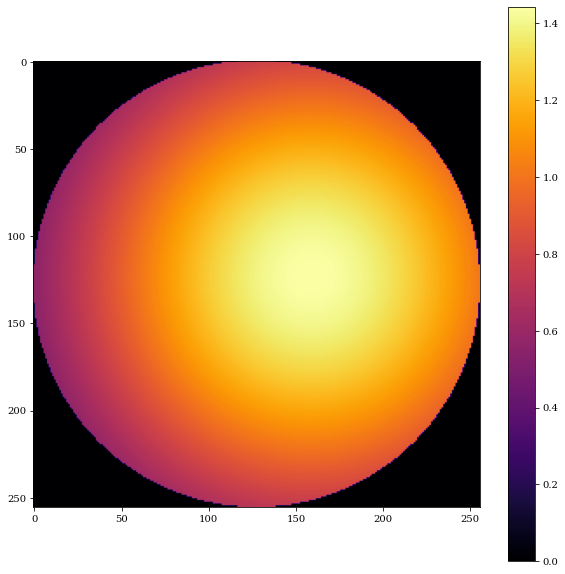

In [7]:
# t_layer_sg = SuperGaussTransmissiveLayer(gaussian_param=jnp.array([0.08,0.08,0.007,-0.006]), p=2, pixel_coords=coords)
t_layer_sg = SuperGaussTransmissiveLayer(
    gaussian_param=jnp.array([0.08, 0.08, 0.0154, -0.0020]), p=2, pixel_coords=coords
)

# (cx,cy)=0.0118,0.0072

plt.imshow(t_layer_sg.get_transmission() * circle)
plt.colorbar()

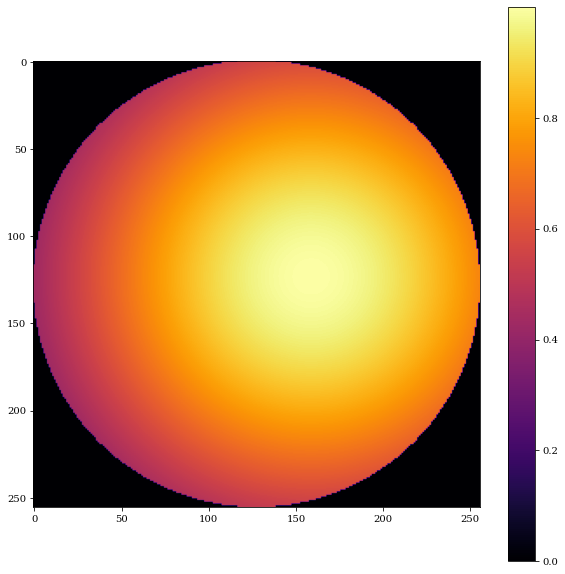

In [8]:
# [var_x, var_y, pos_x, pos_y, A, B]
# 0.05489999, 0.05850005, 0.01669999, 0.00909998, 0.5611    ,
#        0.0441 # prev fit params
# t_layer = GaussTransmissiveLayer(gaussian_param=jnp.array([0.06015824,  0.05799659,  0.007, -0.006]), pixel_coords=coords)
t_layer = GaussTransmissiveLayer(
    gaussian_param=jnp.array([0.06015824, 0.05799659, 0.0154, -0.0020]),
    pixel_coords=coords,
)

plt.imshow(t_layer.get_transmission() * circle)
plt.colorbar()

In [9]:
# Define non-linear detector response
class ApplyBFSPixelResponse(dl.layers.detector_layers.DetectorLayer):
    """
    Applies a pixel response array to the input psf, via a multiplication. This can be
    used to model variations in the inter and intra-pixel sensitivity variations common
    to most detectors.

    We have characterised the BFS detector to have a gamma curve gain response per px.

    ??? abstract "UML"
        ![UML](../../assets/uml/ApplyPixelResponse.png)

    Attributes
    ----------
    pixel_response : Array
        The pixel_response to apply to the input psf in the form of gamma fn coeffs:
        measured_intensity = alpha + beta*real_intensity^gamma
        with    pixel_response[0] = alpha
                pixel_response[1] = beta
                pixel_response[2] = gamma
    luminance_min, luminance_max : float
        The minimum and maximum input luminance values for the pixel response (with which the
        gamma curve was characterised).
    intensity_min, intensity_max : float
        The minimum and maximum output intensity values for the pixel response (with which the
        gamma curve was characterised).
    """

    pixel_response: jnp.array

    def __init__(
        self: dl.layers.detector_layers.DetectorLayer,
        pixel_response: jnp.array,
    ):
        """
        Parameters
        ----------
        pixel_response : Array
            The pixel_response to apply to the input psf. Must be a 2-dimensional array
            equal to size of the psf at time of application.
        """
        super().__init__()

        self.pixel_response = jnp.asarray(pixel_response, dtype=float)

    def norm(self, array):
        min_val, max_val = array.min(), array.max()
        return (array - min_val) / (max_val - min_val)

    def remap(self, array, new_min, new_max):
        min_val, max_val = array.min(), array.max()

        return new_min + (array - min_val) * (new_max - new_min) / (max_val - min_val)

    def apply(self: dl.layers.detector_layers.DetectorLayer, psf: dl.PSF) -> dl.PSF:
        """
        Applies the layer to the PSF.

        Parameters
        ----------
        psf : PSF
            The psf to operate on.

        Returns
        -------
        psf : PSF
            The transformed psf.

        """
        psf_array = jnp.asarray(psf.data, dtype=float)

        # # todo this properly: need to normalise then apply then reset range (easiest way to do without converting cd/m2 to photons)
        # # psf_array = self.pixel_response[0] + self.pixel_response[1]*psf_array**(self.pixel_response[2])
        # # 1. norm
        # norm_psf_array = self.norm(psf_array)

        # # 2. apply pixel response
        # # nonlin_psf = self.pixel_response[0] + self.pixel_response[1]*norm_psf_array**(self.pixel_response[2])
        # nonlin_psf = self.pixel_response[0] + self.pixel_response[1]*jnp.power(norm_psf_array,self.pixel_response[2])

        # # 3. return to original range
        # remapped_psf_array = self.remap(nonlin_psf, psf_array.min(), psf_array.max())

        # psf_obj = dl.PSF(data = remapped_psf_array, pixel_scale = psf.pixel_scale)
        # psf_obj = dl.PSF(data = psf_array**0.8, pixel_scale = psf.pixel_scale)
        psf_obj = dl.PSF(data=psf_array, pixel_scale=psf.pixel_scale)

        # psf_obj = dl.PSF(data = psf_array, pixel_scale = psf.pixel_scale)

        return psf_obj

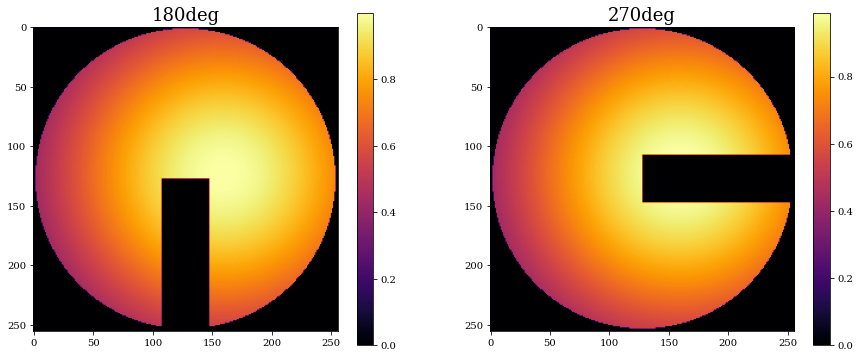

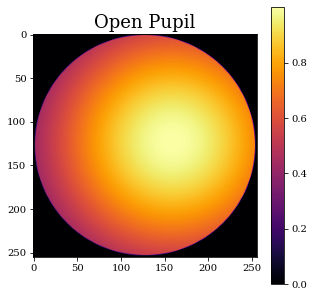

In [10]:
# Zernike aberrations
# zernike_indicies = jnp.arange(4, 22)#jnp.arange(4, 16)
zernike_indicies = jnp.arange(4, 16)
# zernike_indicies = jnp.arange(4, 50)

# zernike_indicies = jnp.arange(4, 29)

cap_transmission = dlu.circle(coords=coords, radius=cap_diameter / 2)
coeffs = jnp.zeros(zernike_indicies.shape)
basis = dlu.zernike_basis(
    js=zernike_indicies, coordinates=coords, diameter=aperture_diameter
)

# Using PointSources instead of single PointSource object to overcome float grad issue when solving for flux
# red_src = dl.PointSources(wavelengths=[red_laser_wl], flux =jnp.asarray([1e13],dtype=float))
red_src = PointSource(
    wavelengths=[red_laser_wl], logflux=jnp.asarray([13], dtype=float)
)

# for amplitude fitting
t_layer_trans = t_layer.get_transmission()
t_layer_valid = jnp.argwhere((t_layer_trans * cap_transmission) != 0)
t_layer_coeffs = t_layer_trans[t_layer_valid[:, 0], t_layer_valid[:, 1]]
CA_coords = jnp.argwhere(cap_transmission != 0)
amp_basis = PixelBasisTransmissiveLayer(
    npix=aperture_npix, pixel_locs=CA_coords, coefficients=t_layer_coeffs
)


spider_angles = [
    180,
    270,
]  # 270 # 0deg is spider pointing vertically up (if looking at 'lower' origin), rotates CW from 0deg
optical_systems = []
transmissions = []
for i in range(len(spider_angles)):
    spider = dlu.spider(coords=coords, width=spider_width, angles=[spider_angles[i]])
    transmission = dlu.combine([cap_transmission, spider])

    layers = [
        # ('intensity', dl.layers.TransmissiveLayer(transmission=intensity_dist*cap_transmission, normalise=False)),
        # ('intensity', amp_basis),
        ("intensity", t_layer),
        # ('intensity', t_layer_sg),
        ("spider", TransmissiveLayer(transmission=transmission, normalise=False)),
        (
            "aperture",
            dl.layers.BasisOptic(
                basis=basis,
                coefficients=coeffs,
                transmission=cap_transmission,
                normalise=False,
            ),
        ),
    ]

    optics = AngularOpticalSystem(
        wf_npixels=wf_npixels,
        diameter=wf_diam,
        layers=layers,
        psf_npixels=psf_npix,
        psf_pixel_scale=psf_pixel_scale,
        oversample=oversample,
    )

    optical_systems.append(optics)
    transmissions.append(transmission)

# Construct Optics
optics_sp270 = optical_systems[1]
optics_sp180 = optical_systems[0]
sp270_trans = transmissions[1]
sp180_trans = transmissions[0]

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.imshow(sp180_trans * optics_sp180.intensity.transmission)
plt.title("180deg")
plt.colorbar()
plt.subplot(1, 2, 2)
plt.imshow(sp270_trans * optics_sp270.intensity.transmission)
plt.title("270deg")
plt.colorbar()

# ----------------------------------------------------------------------------------#
# model of open pupil
tf_op = dl.CoordTransform(compression=jnp.array([1, 1]))
ap_1 = dl.CircularAperture(transformation=tf_op, radius=float(cap_diameter / 2))
ap_1 = ap_1.set("radius", float(cap_diameter / 2))  # idk why radius doesn't set here?
layers = [
    # ('intensity', dl.layers.TransmissiveLayer(transmission=intensity_dist*cap_transmission, normalise=False)),
    # ('intensity', amp_basis),
    ("intensity", t_layer),
    ("front_ap", ap_1),  # atm aperture is separate from its aberrations as a quick test
    # ('aperture', dl.layers.BasisOptic(basis=basis, coefficients=coeffs, transmission=cap_transmission, normalise=False)),
    (
        "aperture",
        dl.layers.BasisOptic(basis=basis, coefficients=coeffs, normalise=False),
    ),
    # ('aperture', BasisOptic(basis=basis, transmission=cap_transmission, coefficients=coeffs, normalise=False)),
]

optics_open_pup = AngularOpticalSystem(
    wf_npixels=wf_npixels,
    diameter=wf_diam,
    layers=layers,
    psf_npixels=psf_npix,
    psf_pixel_scale=jnp.asarray([psf_pixel_scale]),
    oversample=oversample,
)

plt.figure(figsize=(5, 5))
plt.imshow(
    optics_open_pup.intensity.transmission
    * optics_open_pup.front_ap.transmission(coords, aperture_diameter / aperture_npix)
)
# plt.imshow(optics_open_pup.intensity.transmission*optics_open_pup.aperture.transmission)
plt.title("Open Pupil")
plt.colorbar()
# row_start, col_start = 1676, 2532 # Start coord of window on det where data was taken
# row_len, col_len = 86, 76   # window size of recorded data
# psf_hlf_sz = 14             # half window sz of cropped data

# # load in response curve matrices (form of Gamma fn)
# alpha = np.load("data/80us_detector/ALPHA_norm.npy")[row_start:row_start+row_len, col_start:col_start+col_len]
# beta = np.load("data/80us_detector/BETA_norm.npy")[row_start:row_start+row_len, col_start:col_start+col_len]
# gamma = np.load("data/80us_detector/GAMMA_norm.npy")[row_start:row_start+row_len, col_start:col_start+col_len]

# # Crop, anchored on middle (cropped data will be based on max values, but this occurs close enough to the
# # middle to estimate here. + detector response is fairly homogenous over small window)
# middle_row, middle_col = int(alpha.shape[0]/2), int(alpha.shape[1]/2)
# cropped_alpha = alpha[middle_row-psf_hlf_sz:middle_row+psf_hlf_sz, middle_col-psf_hlf_sz:middle_col+psf_hlf_sz]
# cropped_beta = beta[middle_row-psf_hlf_sz:middle_row+psf_hlf_sz, middle_col-psf_hlf_sz:middle_col+psf_hlf_sz]
# cropped_gamma = gamma[middle_row-psf_hlf_sz:middle_row+psf_hlf_sz, middle_col-psf_hlf_sz:middle_col+psf_hlf_sz]

# pixel_response = jnp.array([cropped_alpha, cropped_beta, cropped_gamma])
# detector = dl.LayeredDetector([ApplyBFSPixelResponse(pixel_response=pixel_response)])

In [12]:
# # looking at how gauss pos and var impact open pup psf
# # looking at how pupil sheer impacts open pup psf
# test_gauss_layer1 = GaussTransmissiveLayer(gaussian_param=jnp.array([0.06, 0.06,  0.0, 0.0]), pixel_coords=coords)
# test_gauss_layer2 = GaussTransmissiveLayer(gaussian_param=jnp.array([0.04, 0.04,  0.01, 0.01]), pixel_coords=coords)
# tf = dl.CoordTransform(compression=jnp.array([1,1]))
# ap_1 = dl.CircularAperture(transformation=tf, radius=float(cap_diameter/2))
# ap_1 = ap_1.set("radius", float(cap_diameter/2)) #idk why raidus doesn't set here?
# ap_transmission_1 = ap_1.transmission(coords, aperture_diameter/aperture_npix)
# layers = [
#     ('intensity', test_gauss_layer1),
#     ('sam18', TransmissiveLayer(transmission=sam18_trans, normalise=False)),
#     # ('aperture', dl.layers.BasisOptic(basis=basis, coefficients=coeffs, transmission=ap_transmission_1, normalise=False)),
# ]

# optics_open_pup_1 = AngularOpticalSystem(wf_npixels = wf_npixels,
#                             diameter=wf_diam,
#                             layers=layers,
#                             psf_npixels=psf_npix*5,
#                             psf_pixel_scale=jnp.asarray([psf_pixel_scale]),
#                             oversample=oversample)
# eg_src =PointSource(wavelengths=[red_laser_wl], logflux =jnp.asarray([13],dtype=float))
# tscope_1 = dl.Telescope(optics_open_pup_1, source=eg_src)
# # psf1=optics_open_pup_1.propagate_mono(wavelength=red_laser_wl)
# psf1=tscope_1.model()

# tf = dl.CoordTransform(compression=jnp.array([1,1.02]))
# ap_2 = ap_1.set("transformation", tf)
# ap_transmission_2 = ap_2.transmission(coords, aperture_diameter/aperture_npix)
# dynamic_aperture_cc = dynamic_aperture.set("_pixel_coords", dlu.compress_coords(coords, jnp.array([1.01,1.01])))
# # sam18_trans_c = dynamic_aperture_cc.transmission()
# layers = [
#     ('intensity', test_gauss_layer2),
#     ('sam18', TransmissiveLayer(transmission=sam18_trans, normalise=False)),

#     # ('sam18', TransmissiveLayer(transmission=sam18_trans_c, normalise=False)),
#     # ('aperture', dl.layers.BasisOptic(basis=basis, coefficients=coeffs, transmission=ap_transmission_2, normalise=False)),
# ]

# optics_open_pup_2 = AngularOpticalSystem(wf_npixels = wf_npixels,
#                             diameter=wf_diam,
#                             layers=layers,
#                             psf_npixels=psf_npix*5,
#                             psf_pixel_scale=jnp.asarray([psf_pixel_scale]),
#                             oversample=oversample)
# eg_src = PointSource(wavelengths=jnp.linspace(red_laser_wl*0.995, red_laser_wl*1.005,5), logflux =jnp.asarray([13],dtype=float))
# tscope_2 = dl.Telescope(optics_open_pup_2, source=eg_src)
# # psf2=optics_open_pup_2.propagate_mono(wavelength=red_laser_wl)
# psf2 = tscope_2.model()

# plt.figure(figsize=(30,20))
# plt.subplot(2,3,1)
# # plt.title("Gauss 1")
# # plt.title("Mono Prop")
# plt.title("Open_pup")
# plt.imshow(test_gauss_layer1.get_transmission())
# # plt.imshow(optics_open_pup_1.sam18.transmission)
# plt.colorbar()
# plt.subplot(2,3,2)
# plt.title("Poly Prop - equal weight")
# plt.imshow(test_gauss_layer2.get_transmission())
# # plt.imshow(ap_transmission_2)
# # plt.imshow(optics_open_pup_2.sam18.transmission)
# plt.colorbar()
# plt.subplot(2,3,3)
# plt.subplot(2,3,4)
# plt.imshow(psf1, norm=PowerNorm(0.2))
# plt.colorbar()
# plt.subplot(2,3,5)
# plt.imshow(psf2, norm=PowerNorm(0.2))
# plt.colorbar()
# resid = (psf1-psf2)#/np.sqrt(psf1)
# plt.subplot(2,3,6)
# plt.title("1-2")
# plt.imshow(resid, cmap='bwr', norm=CenteredNorm())
# plt.colorbar()

# # plt.gcf().savefig(save_dir+"1.png")

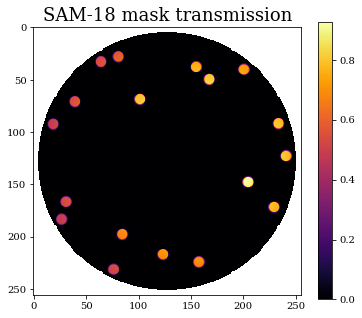

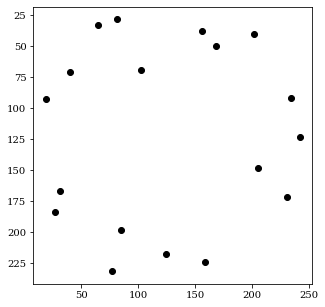

In [11]:
### sam18 model
scale = sam18_diameter / 7.06e-3  # scaled up for toliman setup
sam18_aperture = dlu.circle(coords=coords, radius=sam18_diameter / 2)

r = 0.147273e-3 * scale  # (m)
# r = 0.1e-3*scale  # (m)

mask_coords = (
    np.array(
        [  # (m) SAM-18
            0.569978,
            2.20621,
            -2.22306,
            1.14997,
            -2.49369,
            2.09376,
            1.25201,
            2.91247,
            2.54021,
            -0.110373,
            1.58209,
            -2.86584,
            -2.70485,
            -1.79699,
            2.74591,
            0.869195,
            -2.56407,
            0.796841,
            2.94615,
            -1.45332,
            -0.140611,
            3.24148,
            -1.02159,
            3.03439,
            -1.00524,
            -3.09706,
            -1.68181,
            -0.737597,
            1.10577,
            -2.74708,
            -2.84016,
            -1.32510,
            1.99349,
            -1.21580,
            -1.61688,
            -2.50640,
        ]
    )
    * 1e-3
    * scale
)

mask_coords = np.flip(mask_coords)  # flip x and y for dLux coords convention

mask_coords = mask_coords.reshape(mask_coords.shape[0] // 2, 2)

dynamic_aperture = DynamicAperture(
    subap_centers=[mask_coords],
    rmax=r,
    pixel_coords=coords,
    pattern_rot=0,  # 240*np.pi/180,#-25*np.pi/180,
    npix=aperture_npix,
    prim_diam=sam18_diameter,
    ap_noll_idxs=np.array([1]),  # piston only
)

# for solving transmission only (save on compute time here)
dynamic_aperture_t = DynamicAperture(
    subap_centers=[mask_coords],
    rmax=r,
    pixel_coords=coords,
    pattern_rot=0,  # 240*np.pi/180,#-25*np.pi/180,
    npix=aperture_npix,
    prim_diam=sam18_diameter,
    ap_noll_idxs=None,  # piston only
)

sam18_trans = dynamic_aperture_t.transmission()

layers = [
    # ('intensity', dl.layers.TransmissiveLayer(transmission=intensity_dist*sam18_aperture, normalise=False)),
    # ('intensity', amp_basis),
    ("intensity", t_layer),
    # ('intensity', GaussTransmissiveLayer(gaussian_param=jnp.array([0.1,0.1,20e-3,15e-3,0.5,0]), pixel_coords=coords)),
    ("sam18", TransmissiveLayer(transmission=sam18_trans, normalise=False)),
    # ('sam18', dynamic_aperture_t),
    # ('aperture', dl.layers.BasisOptic(basis=basis, coefficients=coeffs, transmission=sam18_aperture, normalise=False)),
    (
        "aperture",
        dl.layers.BasisOptic(basis=basis, coefficients=coeffs, normalise=False),
    ),
    # ('aperture', BasisOptic(basis=basis, transmission=jnp.ones(shape=(basis.shape[1], basis.shape[1])), coefficients=coeffs, normalise=False)),
    # ('aperture', BasisOptic(basis=basis, transmission=sam18_trans, coefficients=coeffs, normalise=False)),
]

sam18_psf_npix = 270
optics_mask = AngularOpticalSystem(
    wf_npixels=wf_npixels,
    diameter=wf_diam,
    layers=layers,
    psf_npixels=sam18_psf_npix,
    psf_pixel_scale=jnp.asarray([psf_pixel_scale]),
    oversample=oversample,
)
t_model = dl.Telescope(optics_mask, source=red_src)

plt.figure(figsize=(6, 5))
plt.title("SAM-18 mask transmission")
nan_env = sam18_aperture.at[sam18_aperture == 0].set(
    jnp.nan
)  # set zero transmission to nan for better visualisation of mask pattern
plt.imshow(
    optics_mask.intensity.transmission * optics_mask.sam18.transmission * nan_env
)
# plt.imshow(optics_mask.intensity.transmission*optics_mask.aperture.transmission*nan_env)

# plt.imshow(optics_mask.intensity.transmission*optics_mask.sam18.transmission()*nan_env)

plt.colorbar()

plt.figure(figsize=(5, 5))
for coord in mask_coords:
    # plt.plot(coord[0], coord[1], 'ro')
    plt.plot(
        coord[0] * (aperture_npix / aperture_diameter) + aperture_npix / 2,
        coord[1] * (aperture_npix / aperture_diameter) + aperture_npix / 2,
        "ko",
    )
plt.gca().invert_yaxis()
# plt.xlim([-0.1,0.1])
# plt.ylim([-0.1,0.1])

In [12]:
open_pup_instrument = dl.Telescope(
    optics_open_pup,
    source=(
        "source",
        PointSource(
            wavelengths=[red_laser_wl],
            logflux=jnp.asarray([10 - np.log(1.4)], dtype=float),
        ),
    ),
)
instrument_sam18_0deg = dl.Telescope(
    optics_mask,
    source=(
        "source",
        PointSource(
            wavelengths=[red_laser_wl],
            logflux=jnp.asarray([12 - np.log(0.4)], dtype=float),
        ),
    ),
)

In [13]:
# generate fake data
# add sys aberrations, psf px scale offset, noise, and amplitude shift
aberr_coeffs = (
    jr.normal(jr.PRNGKey(10), shape=(zernike_indicies.shape[0], 1)) * red_laser_wl / 50
)
t_coeffs = jnp.array([0.04, 0.04, 0.0, -0.00])
p_scale_muck = psf_pixel_scale * 1.1

dummy_open_model = open_pup_instrument.set(
    "aperture.coefficients", aberr_coeffs.flatten()
)
dummy_open_model = dummy_open_model.set("intensity.gauss_param", t_coeffs)
dummy_open_model = dummy_open_model.set("psf_pixel_scale", jnp.asarray([p_scale_muck]))

dummy_sam18_model = instrument_sam18_0deg.set(
    "aperture.coefficients", aberr_coeffs.flatten()
)
dummy_sam18_model = dummy_sam18_model.set("intensity.gauss_param", t_coeffs)
dummy_sam18_model = dummy_sam18_model.set(
    "psf_pixel_scale", jnp.asarray([p_scale_muck])
)

sam18_data = dummy_sam18_model.model()
photons = jr.poisson(jr.key(1), sam18_data)
read_electrons = 0.1 * jr.normal(jr.key(2), shape=sam18_data.shape)
sam18_data_noisy = photons + read_electrons

open_pup_data = dummy_open_model.model()
photons = jr.poisson(jr.key(3), open_pup_data)
read_electrons = 0.1 * jr.normal(jr.key(2), shape=open_pup_data.shape)
open_pup_data_noisy = photons + read_electrons

In [34]:
OPD = dummy_open_model.aperture.eval_basis() * nan_env
stdev = np.nanstd(OPD)  # RMS TWFE
PV = np.nanmax(OPD) - np.nanmin(OPD)  # PV TWFE
print("RMS TWFE: {:.3f} nm, PV TWFE: {:.3f} nm".format(stdev * 1e9, PV * 1e9))
print(
    "RMS TWFE: {:.3f} lam, PV TWFE: {:.3f} lam".format(
        stdev / red_laser_wl, PV / red_laser_wl
    )
)

RMS TWFE: 40.095 nm, PV TWFE: 271.844 nm
RMS TWFE: 0.063 lam, PV TWFE: 0.428 lam


<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:20: SyntaxWarning: invalid escape sequence '\l'
/var/folders/2j/vdv93b7508qfh_tr2nx03dh80000gp/T/ipykernel_85261/1636854395.py:20: SyntaxWarning: invalid escape sequence '\l'
  cbar.set_label("Optical Path Difference ($\lambda$)", fontsize=20)


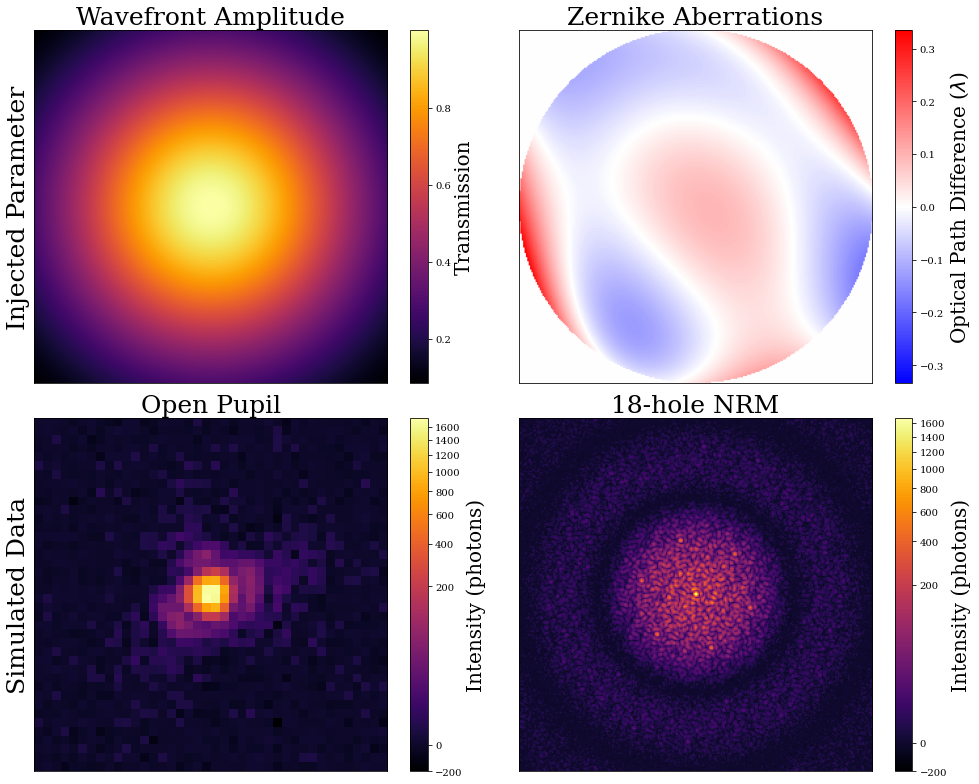

In [31]:
plt.figure(figsize=(14, 11))
plt.subplot(2, 2, 1)
im = plt.imshow(dummy_open_model.intensity.get_transmission())
plt.xticks([])
plt.yticks([])
plt.title("Wavefront Amplitude", fontsize=25)
cbar = plt.colorbar(im)
cbar.set_label("Transmission", fontsize=20)
plt.ylabel("Injected Parameter", fontsize=25)
plt.subplot(2, 2, 2)
im = plt.imshow(
    dummy_open_model.aperture.eval_basis() / red_laser_wl,
    cmap="bwr",
    norm=CenteredNorm(),
)
plt.xticks([])
plt.yticks([])
plt.title("Zernike Aberrations", fontsize=25)
cbar = plt.colorbar(im)
cbar.set_label("Optical Path Difference ($\lambda$)", fontsize=20)

plt.subplot(2, 2, 3)
im = plt.imshow(open_pup_data_noisy, norm=PowerNorm(0.3))
plt.xticks([])
plt.yticks([])
plt.title("Open Pupil", fontsize=25)
cbar = plt.colorbar(im)
cbar.set_label("Intensity (photons)", fontsize=20)
plt.ylabel("Simulated Data", fontsize=25)
plt.subplot(2, 2, 4)
im = plt.imshow(sam18_data_noisy, norm=PowerNorm(0.3))

plt.xticks([])
plt.yticks([])
plt.title("18-hole NRM", fontsize=25)
cbar = plt.colorbar(im)
cbar.set_label("Intensity (photons)", fontsize=20)

plt.tight_layout()

In [14]:
frames_i = jnp.asarray([0])

In [35]:
# instrument_sam18_0deg = dl.Telescope(optics=optics_mask, source=('source', PointSource(wavelengths=[red_laser_wl], logflux=jnp.asarray([12-np.log(0.4)],dtype=float)))).set("sam18.rotation", jnp.array(optics_mask.sam18.rotation+rots[0]*np.pi/180))
# instrument_sam18_90deg = dl.Telescope(optics=optics_mask, source=('source', PointSource(wavelengths=[red_laser_wl], logflux=jnp.asarray([12-np.log(0.35)],dtype=float)))).set("sam18.rotation", jnp.array(optics_mask.sam18.rotation+rots[1]*np.pi/180))
# instrument_sam18_0deg = dl.Telescope(optics=optics_mask, source=('source', PointSource(wavelengths=[red_laser_wl], logflux=jnp.asarray([14-jnp.log(0.8)],dtype=float)))).set("sam18._pattern_rot", jnp.array(optics_mask.sam18._pattern_rot+rots[0]*np.pi/180))
# instrument_sam18_90deg = dl.Telescope(optics=optics_mask, source=('source', PointSource(wavelengths=[red_laser_wl], logflux=jnp.asarray([14-jnp.log(0.8)],dtype=float)))).set("sam18._pattern_rot", jnp.array(optics_mask.sam18._pattern_rot+rots[1]*np.pi/180))
# instrument_sam18_0deg = dl.Telescope(optics=optics_mask, source=('source', PointSource(wavel|engths=[red_laser_wl], logflux=jnp.asarray([12-np.log(0.4)],dtype=float)))).set("aperture.tf.rotation", jnp.array(optics_mask.aperture.tf.rotation+rots[0]*np.pi/180))

configs = [
    # instrument_sp180.set("aperture.coefficients", est_coeffs.flatten()),
    # instrument_sp270.set("aperture.coefficients", est_coeffs.flatten()),
    # instrument_mask.set("aperture.coefficients", prev_fit_coeffs),
    open_pup_instrument,
    instrument_sam18_0deg,
    # instrument_sam18_90deg,
    # dl.Telescope(optics=optics_mask, source=('source', PointSource(wavelengths=[red_laser_wl], logflux=jnp.asarray([15-jnp.log(1.2)],dtype=float)))).set("sam18.rotation", jnp.array(optics_mask.sam18.rotation+rots[0]*np.pi/180)),
    # dl.Telescope(optics=optics_mask, source=('source', PointSource(wavelengths=[red_laser_wl], logflux=jnp.asarray([15-jnp.log(1.2)],dtype=float)))).set("sam18.rotation", jnp.array(optics_mask.sam18.rotation+rots[1]*np.pi/180)),
    # instrument_mask,
    # mask_config,
]
models = []
for i, instrument_model in enumerate(configs):
    # make x copies of the model, one for each frame of data
    temp_config = [instrument_model] * frames_i.shape[0]
    models.append(temp_config)

In [36]:
param_dict = {
    "aperture.coefficients": optax.adam(
        optax.join_schedules(
            schedules=[optax.constant_schedule(0.0), optax.constant_schedule(1e-10)],
            boundaries=[1000],
        )
    ),
    "source.position": optax.adam(learning_rate=1e-9),
    "source.logflux": optax.adam(learning_rate=1e-3),  # optax.adam(learning_rate=1e-3),
    "psf_pixel_scale": optax.adam(
        learning_rate=1e-5
    ),  # optax.adam(learning_rate=1e-5),
    # 'intensity.coefficients',
    "intensity.gauss_param": optax.adam(
        optax.join_schedules(
            schedules=[optax.constant_schedule(0.0), optax.constant_schedule(1e-5)],
            boundaries=[1000],
        )
    ),  # optax.adam(optax.join_schedules(schedules=[optax.constant_schedule(0.0), optax.constant_schedule(1e-5)],boundaries=[6000])),
    # 'intensity.p':optax.adam(optax.join_schedules(schedules=[optax.constant_schedule(0.0), optax.constant_schedule(1e-4)],boundaries=[8000])),
    # "front_ap.compression": optax.adam(learning_rate=1e-4),
    # 'aperture.tf.compression': optax.adam(optax.join_schedules(schedules=[optax.constant_schedule(0.0), optax.constant_schedule(1e-4)],boundaries=[0])),
}

params_s18_dict = {
    "aperture.coefficients": optax.adam(
        optax.join_schedules(
            schedules=[optax.constant_schedule(0.0), optax.constant_schedule(1e-10)],
            boundaries=[1000],
        )
    ),
    # 'sam18.rotation':optax.adam(learning_rate=1e-5),
    # 'sam18._ap_centers':optax.adam(learning_rate=1e-6),#sam18._rmax',
    # 'sam18._rmax': optax.adam(learning_rate=1e-6),#optax.adam(optax.join_schedules(schedules=[optax.constant_schedule(0.0), optax.constant_schedule(1e-6)],boundaries=[3000])), #optax.adam(learning_rate=1e-6), # 'sam18._compressions'
    "source.position": optax.adam(learning_rate=1e-9),
    "source.logflux": optax.adam(learning_rate=1e-3),
    "psf_pixel_scale": optax.adam(learning_rate=1e-5),
    # 'intensity.coefficients',
    "intensity.gauss_param": optax.adam(
        optax.join_schedules(
            schedules=[optax.constant_schedule(0.0), optax.constant_schedule(1e-5)],
            boundaries=[1000],
        )
    ),
    # 'intensity.p':optax.adam(optax.join_schedules(schedules=[optax.constant_schedule(0.0), optax.constant_schedule(1e-4)],boundaries=[6000])),
    # 'aperture.tf.compression': optax.adam(optax.join_schedules(schedules=[optax.constant_schedule(0.0), optax.constant_schedule(1e-6)],boundaries=[0])),
    # 'aperture.tf.rotation': optax.adam(learning_rate=0.0),
}

In [37]:
params = list(param_dict.keys())
params_s18 = list(params_s18_dict.keys())

optimisers = list(param_dict.values())
optimisers_s18 = list(params_s18_dict.values())

In [38]:
# Create optimisation managers - one per spider configuration
OMS = []
# config_lbs = ['sam18_0deg', 'sam18_90deg']
config_lbs = ["open_pupil", "sam18_0deg"]
for i in range(len(models)):
    # if ph_prior and i == 2:
    #     # assuming that if there is a phase prior, it is the last model
    #     om = OptimManager(
    #         models=models[i],
    #         data=linear_spider,
    #         params=params_s18,
    #         loss_fn="poisson", # poisson loss for photon counting
    #         optimisers=optimisers_s18,
    #         jointly_fit_params=["sam18.rotation"],
    #         # loss_fn_kwargs={"data_mask": eg_splodge_mask, "model_mask": splodges_mask}, # mask out low SNR regions
    #         # loss_fn_kwargs={"stdev_data": stdev_linear_spider**(5/4)},

    #     )
    # else:
    #     om = OptimManager(
    #         models=models[i],
    #         data=linear_imgs[:,i,:,:],
    #         params=params,
    #         loss_fn="poisson", # poisson loss for photon counting
    #         # loss_fn_kwargs={"data_mask": img_masks[0,i,:,:]},
    #         optimisers=optimisers,
    #         jointly_fit_params=["spider.rotation"]
    #         # jointly_fit_params=["spider.rotation"], # spider rotation should be same over time and so on.. This is for params that should be fit across frames
    #     )
    if i == 0:
        om = OptimManager(
            models=models[i],
            data=[open_pup_data_noisy],
            params=params,
            # loss_fn="diff2_ph_reg",
            loss_fn="chi2",  # poisson loss for photon counting
            optimisers=optimisers,
            # jointly_fit_params=["aperture.tf.compression"],#["sam18.rotation"], # sam18 rotation should be same over time
            loss_fn_kwargs={"stdev": [], "readnoise": BFS_rn},
        )
    else:
        om = OptimManager(
            models=models[i],
            data=[sam18_data_noisy],
            params=params_s18,
            # loss_fn="diff2_ph_reg",
            loss_fn="chi2",
            optimisers=optimisers_s18,
            # jointly_fit_params=["sam18.rotation"], # sam18 rotation should be same over time
            loss_fn_kwargs={"stdev": [], "readnoise": BFS_rn},
            # loss_fn_kwargs={"pupil_phase": sam18_init_basis/red_laser_wl, "pupil_mask": sam18_trans},
        )

    OMS.append(om)

# Create a joint optimisation manager to optimise the system aberrations over both spider configs
optimisation_manager = JointOptimManager(
    optim_managers=OMS,
    jointly_fit_params=[
        "aperture.coefficients",
        "intensity.gauss_param",
        "psf_pixel_scale",
    ],  # , "intensity.gauss_param","intensity.p", "psf_pixel_scale"],
    # jointly_fit_params=["intensity.p", "psf_pixel_scale", "intensity.gauss_param"],
)

In [39]:
optimisation_manager.run_optimisation(num_steps=8000)

# filenames = [save_dir+"red_0deg_stored_params_dict.pkl"]
save_dir = "data/dummy/"
filenames = [
    save_dir + "red_open_pupil_stored_params_stage2.pkl",
    save_dir + "red_sam18_0deg_stored_params_stage1.pkl",
    #  save_dir+"red_sam18_90deg_stored_params_dict_noll50.pkl",
]
# if ph_prior:
# filenames.append(save_dir+"red_sam18_stored_params_dict_r4_3configs.pkl")

optimisation_manager.save_stored_params(filenames=filenames)

Loss: 10682.9087: 100%|██████████| 8000/8000 [03:59<00:00, 33.45it/s] 


Stored parameters saved to data/dummy/red_open_pupil_stored_params_stage2.pkl
Stored parameters saved to data/dummy/red_sam18_0deg_stored_params_stage1.pkl


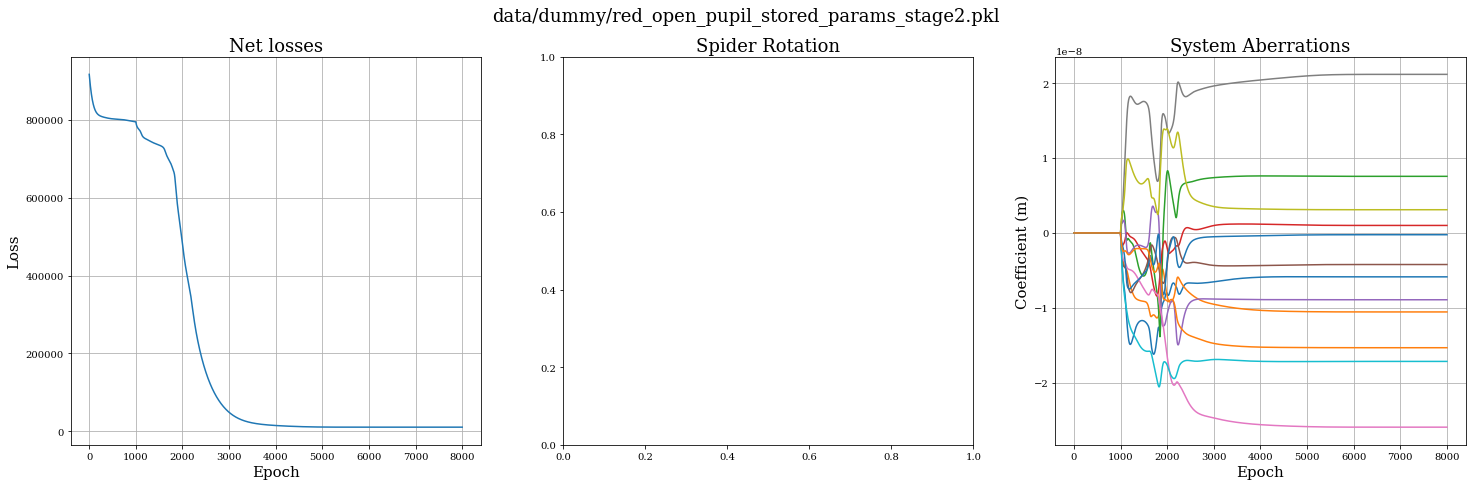

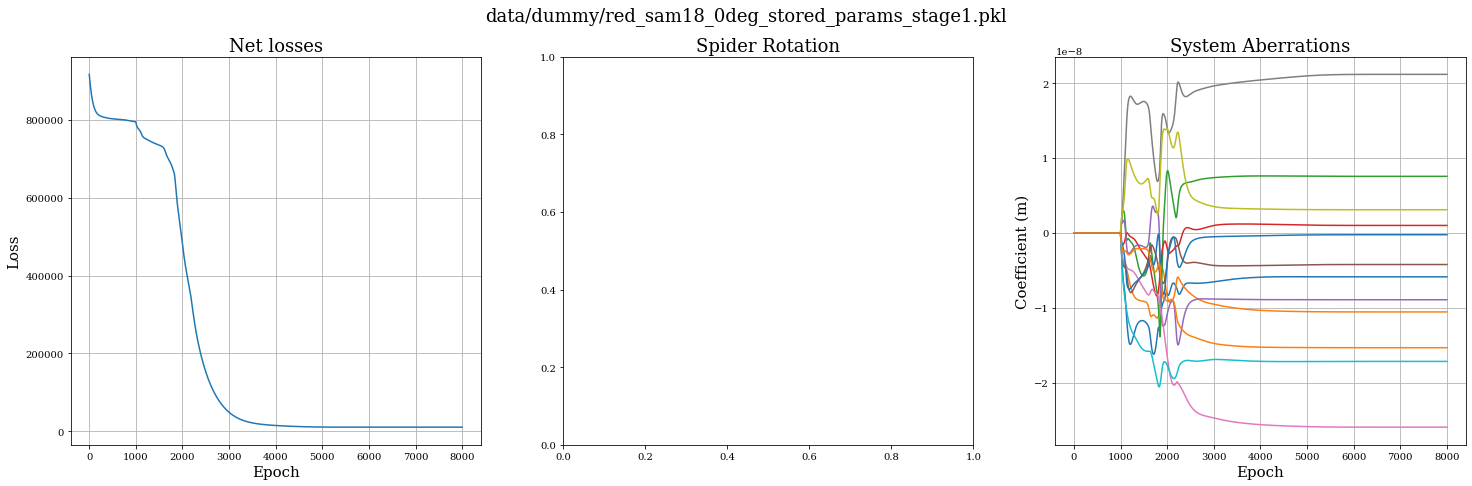

In [40]:
for config_i, filename in enumerate(filenames):
    try:
        stored_params_dict = pickle.load(open(filename, "rb"))
        plt.figure(figsize=(25, 7))
        plt.suptitle(filename)
        plt.subplot(1, 3, 1)
        plt.title("Net losses")
        plt.plot(stored_params_dict["net loss"])
        plt.xlabel("Epoch")
        plt.grid()
        plt.ylabel("Loss")

        plt.subplot(1, 3, 3)
        plt.title("System Aberrations")
        coeffs_arr = np.asarray(stored_params_dict["aperture.coefficients"])[:, 0, :]
        for l in range(coeffs_arr.shape[-1]):
            label = "Coeff " + str(zernike_indicies[l])
            plt.plot(coeffs_arr[:, l], label=label)
        # plt.legend()
        plt.ylabel("Coefficient (m)")
        plt.xlabel("Epoch")
        plt.grid()

        plt.subplot(1, 3, 2)
        plt.title("Spider Rotation")
        spider_rot_arr = np.asarray(stored_params_dict["sam18.rotation"])[:, 0, 0]
        # spider_rot_arr = np.asarray(stored_params_dict["sam18.rotation"])[:,0,0]

        # plt.plot(spider_rot_arr, '.')
        plt.ylabel("Rotation (rad)")
        plt.xlabel("Epoch")
        plt.legend()
        plt.grid()
    except:
        pass

Save figures for each model fit, for both configs

In [41]:
config_stored_params = [
    pickle.load(open(filenames[0], "rb")),
    pickle.load(open(filenames[1], "rb")),
    # pickle.load(open(filenames[2], 'rb')),
]
# config_models = optimisation_manager.models
config_labels = config_lbs  # ,["sam18"] #["sp180", "sp270","sam18"]
opt_params = [params, params_s18]  # [params, params_s18, params_s18]
opt_datas = [[open_pup_data_noisy], [sam18_data_noisy]]

In [42]:
# eg_model = optimisation_manager.models[1][0]
config_models = optimisation_manager.models
for model_i in range(len(config_models)):
    print("Model config {}".format(str(model_i)))
    eg_model = optimisation_manager.models[model_i][0]
    save_dict = {}
    if model_i == 0:
        for param in params:
            print("{}: {}".format(param, eg_model.get(param)))
            save_dict[param] = eg_model.get(param)
    else:
        for param in params_s18:
            print("{}: {}".format(param, eg_model.get(param)))
            save_dict[param] = eg_model.get(param)

    with open(save_dir + "config{}_stage2_finalParams.pkl".format(model_i), "wb") as f:
        pickle.dump(save_dict, f)

Model config 0
aperture.coefficients: [-5.85648505e-09 -1.05411298e-08  7.55943687e-09  1.00468413e-09
 -8.91515279e-09 -4.21084959e-09 -2.59213165e-08  2.11716263e-08
  3.10196653e-09 -1.71449693e-08 -2.34394963e-10 -1.53172811e-08]
source.position: [ 5.09703622e-09 -2.65134482e-08]
source.logflux: [9.66864772]
psf_pixel_scale: [0.41888814]
intensity.gauss_param: [3.98805799e-02 3.98649061e-02 3.53467913e-05 1.34448458e-05]
Model config 1
aperture.coefficients: [-5.85648505e-09 -1.05411298e-08  7.55943687e-09  1.00468413e-09
 -8.91515279e-09 -4.21084959e-09 -2.59213165e-08  2.11716263e-08
  3.10196653e-09 -1.71449693e-08 -2.34394963e-10 -1.53172811e-08]
source.position: [-1.78240419e-09 -6.40090105e-09]
source.logflux: [12.92370275]
psf_pixel_scale: [0.41888814]
intensity.gauss_param: [3.98805799e-02 3.98649061e-02 3.53467913e-05 1.34448458e-05]


In [25]:
# dummy_coeffs = config_dict["intensity.coefficients"][-1,0,:]
# new_amp = amp_basis.set("coefficients", dummy_coeffs)
# plt.figure(figsize=(15,5))
# plt.subplot(3,1,1)
# plt.title("init")
# plt.imshow(amp_basis.calc_transmission())
# plt.colorbar()
# plt.subplot(3,1,2)
# plt.title("opt")
# plt.imshow(new_amp.calc_transmission())
# plt.colorbar()
# plt.subplot(3,1,3)
# plt.title("init-opt")
# resid=amp_basis.calc_transmission() -  new_amp.calc_transmission()
# plt.imshow(resid, cmap='bwr', norm=CenteredNorm())
# plt.colorbar()

In [208]:
# eg_model_1 = optimisation_manager.models[0][0]
# eg_model_2 = optimisation_manager.models[1][0]

# plt.figure(figsize=(12,5))
# plt.subplot(1,2,1)
# plt.title("Model config {}".format(config_labels[0]))
# plt.imshow(eg_model_1.sam18.transmission())
# plt.subplot(1,2,2)
# plt.title("Model config {}".format(config_labels[1]))
# plt.imshow(eg_model_2.sam18.transmission())

In [233]:
# t, b = current_config.aperture.calculate()
# plt.imshow(b/red_laser_wl, cmap='bwr', norm=CenteredNorm())
# plt.colorbar()

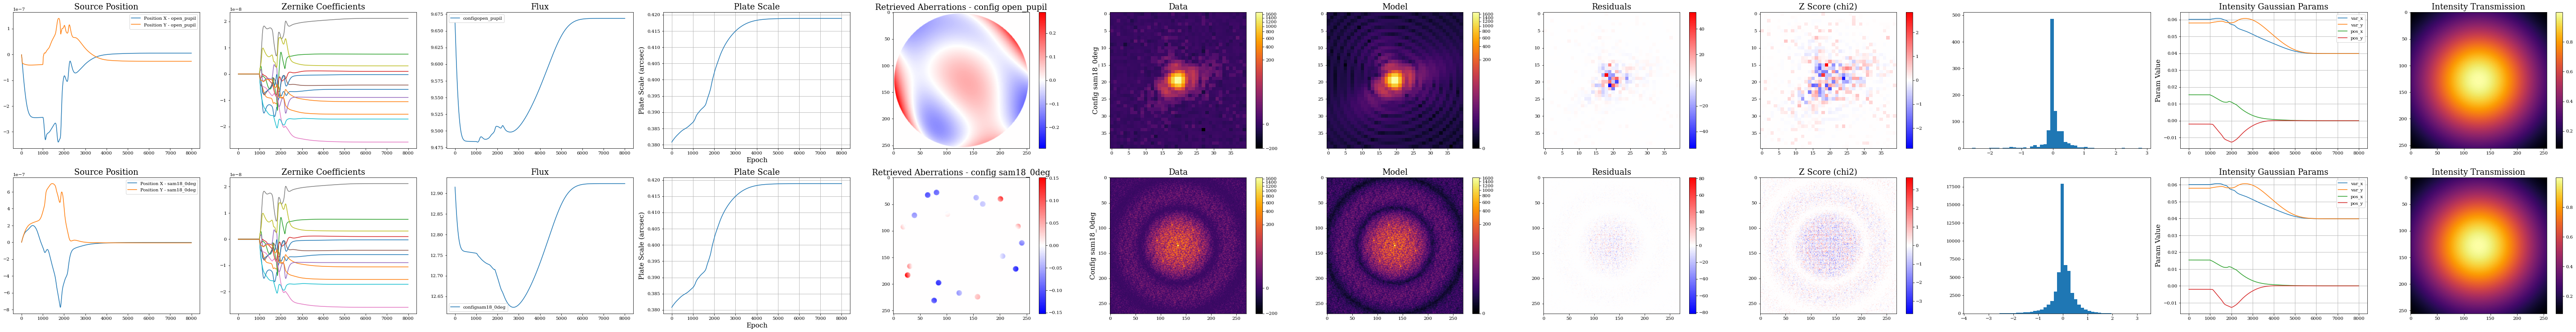

In [26]:
nrow, ncol = 3, 12
for frame_n in range(frames_i.shape[0]):
    plt.figure(figsize=(80, 15))
    it = 1
    for config_i, config_dict in enumerate(config_stored_params):

        plt.subplot(nrow, ncol, it)
        pos = np.asarray(config_dict["source.position"])
        Positions_x = pos[:, frame_n, 0]
        Positions_y = pos[:, frame_n, 1]
        plt.plot(Positions_x, label="Position X - {}".format(config_labels[config_i]))
        plt.plot(Positions_y, label="Position Y - {}".format(config_labels[config_i]))
        plt.title("Source Position")
        plt.legend()
        it += 1

        plt.subplot(nrow, ncol, it)
        coeffs_arr = np.asarray(config_dict["aperture.coefficients"])[:, frame_n, :]
        for l in range(coeffs_arr.shape[-1]):
            label = "Coeff " + str(zernike_indicies[l])
            plt.plot(coeffs_arr[:, l], label=label)
        # plt.legend()
        plt.title("Zernike Coefficients")
        it += 1

        plt.subplot(nrow, ncol, it)
        fluxes_arr = np.asarray(config_dict["source.logflux"])
        plt.plot(
            fluxes_arr[:, frame_n, :], label="config{}".format(config_labels[config_i])
        )
        plt.title("Flux")
        plt.legend()
        it += 1

        # plt.subplot(nrow,ncol,it)
        # # if config_i <2:
        # #     spider_rot_arr = np.asarray(config_dict["spider.rotation"])
        # # else:
        # #     spider_rot_arr = np.asarray(config_dict["sam18.rotation"])
        # if config_i >0:
        #     spider_rot_arr = np.asarray(config_dict["sam18.rotation"])
        #     # spider_rot_arr = np.asarray(config_dict["aperture.tf.rotation"])

        #     # plt.plot(spider_rot_arr[:,frame_n,:], label="Mask {}".format(config_labels[config_i])) # any of the models here will yield same result for jointly fit
        #     plt.plot(spider_rot_arr[:,frame_n], label="Mask {}".format(config_labels[config_i]))
        # plt.ylabel("Rotation (rad)")
        # plt.xlabel("Epoch")
        # plt.legend()
        # it += 1

        plt.subplot(nrow, ncol, it)
        plate_scale_arr = np.asarray(config_dict["psf_pixel_scale"])[:, frame_n]
        plt.plot(plate_scale_arr)
        plt.title("Plate Scale")
        plt.grid()
        plt.xlabel("Epoch")
        plt.ylabel("Plate Scale (arcsec)")
        it += 1

        # plt.subplot(nrow, ncol, it)
        # if config_i == 0:
        #     compress = config_dict["front_ap.compression"]
        #     compress_x, compress_y = compress[:, frame_n, 0], compress[:, frame_n, 1]
        #     plt.plot(compress_x, label="x")
        #     plt.plot(compress_y, label="y")
        #     plt.title("Compression")
        #     plt.legend()

        # # if config_i > 0:
        # #     loc_x = np.asarray(config_dict["sam18._ap_centers"])[:,frame_n,:,0].T
        # #     loc_y = np.asarray(config_dict["sam18._ap_centers"])[:,frame_n,:,1].T

        # #     for hole_i, curve in enumerate(loc_x):
        # #         plt.plot(curve, label="X{}".format(hole_i))
        # #         plt.plot(loc_y[hole_i], '--', label="Y{}".format(hole_i))

        # # # # # plt.legend()
        # #     plt.title("Hole pos")
        # it += 1

        # plt.subplot(nrow,ncol,it)
        # # # compress_x = np.asarray(config_dict["sam18._compressions"])[:,frame_n,:,0].T
        # # # compress_y = np.asarray(config_dict["sam18._compressions"])[:,frame_n,:,1].T
        # # # for hole_i, curve in enumerate(compress_x):
        # # #     plt.plot(curve, label="X{}".format(hole_i))
        # # #     plt.plot(compress_y[hole_i], '--', label="Y{}".format(hole_i))
        # # # plt.title("Hole compression")
        # if config_i > 0:
        #     radii = np.asarray(config_dict["sam18._rmax"])[:,frame_n,:].T
        #     for hole_i, curve in enumerate(radii):
        #         plt.plot(curve, label="X{}".format(hole_i))

        # plt.title("Hole radii")
        # it+=1

        # current_config = config_models[config_i][frame_n]
        current_config = models[config_i][0]
        for key in config_dict:
            if key in opt_params[config_i]:
                current_config = current_config.set(key, config_dict[key][-1, frame_n])
        plt.subplot(nrow, ncol, it)
        # print(config.source.spectrum.wavelengths)
        # t, opd = current_config.aperture.calculate()
        opd = current_config.aperture.eval_basis()
        trans = 1  # config.spider.transmission
        if config_i == 0:
            plt.imshow(
                opd
                * trans
                / red_laser_wl
                * current_config.front_ap.transmission(
                    coords=coords, pixel_scale=aperture_diameter / aperture_npix
                ),
                cmap="bwr",
                norm=CenteredNorm(),
            )
        else:
            plt.imshow(
                opd * trans / red_laser_wl * current_config.sam18.transmission,
                cmap="bwr",
                norm=CenteredNorm(),
            )
        plt.title("Retrieved Aberrations - config {}".format(config_labels[config_i]))
        plt.colorbar()
        it += 1

        plt.subplot(nrow, ncol, it)
        # scaled_data = optimisation_manager.OptimManagers[config_i].data[frame_n]
        scaled_data = opt_datas[config_i][frame_n]

        norm_psf = PowerNorm(0.2, vmax=scaled_data.max(), vmin=scaled_data.min())
        plt.imshow(scaled_data, norm=norm_psf)
        plt.colorbar()
        plt.ylabel("Config {}".format(config_labels[i]))
        plt.title("Data")
        it += 1

        plt.subplot(nrow, ncol, it)
        model_psf = current_config.model()
        model_psf = model_psf.at[scaled_data == 0.0].set(0.0)
        norm_psf = PowerNorm(0.2, vmax=model_psf.max(), vmin=model_psf.min())
        # if config_i <2:
        #     plt.imshow(model_psf*img_masks[frame_n][config_i], norm=norm_psf)
        # else:
        #     plt.imshow(model_psf, norm=norm_psf)
        plt.imshow(model_psf, norm=norm_psf)

        plt.title("Model")
        plt.colorbar()
        it += 1

        plt.subplot(nrow, ncol, it)
        resid = scaled_data - model_psf
        plt.imshow(
            resid, cmap="bwr", vmax=np.abs(resid).max(), vmin=-np.abs(resid).max()
        )
        plt.colorbar()
        plt.title("Residuals")
        it += 1

        plt.subplot(nrow, ncol, it)
        # zsc = resid/scaled_data**0.5
        poiss_err = scaled_data**0.5
        # zsc = ((scaled_data-current_config.model())/jnp.sqrt(stdevs_dict[config_labels[config_i]]**2+BFS_rn**2))
        zsc = (scaled_data - current_config.model()) / jnp.sqrt(
            poiss_err**2 + BFS_rn**2
        )

        valid_mask = jnp.isfinite(zsc) & (scaled_data > 0)
        zsc = jnp.where(valid_mask, zsc, 0)

        plt.imshow(zsc, cmap="bwr", norm=CenteredNorm())
        plt.colorbar()
        # plt.title('Z Score (poiss)')
        plt.title("Z Score (chi2)")
        it += 1

        plt.subplot(nrow, ncol, it)
        zsc = (scaled_data - current_config.model()) / jnp.sqrt(
            poiss_err**2 + BFS_rn**2
        )
        non_zero_zsc = zsc[valid_mask]
        plt.hist(non_zero_zsc.flatten(), bins=50)
        it += 1

        plt.subplot(nrow, ncol, it)
        gauss_params = np.asarray(config_dict["intensity.gauss_param"])[:, frame_n, :]
        param_labels = ["var_x", "var_y", "pos_x", "pos_y"]
        for param_i, p in enumerate(gauss_params.T):
            plt.plot(p, label="{}".format(param_labels[param_i]))
        # ax2 = plt.gca().twinx()
        # ps =  np.asarray(config_dict["intensity.p"])[:,frame_n,:]
        # ax2.plot(ps, label='p')

        plt.title("Intensity Gaussian Params")
        plt.legend()
        plt.ylabel("Param Value")
        plt.grid()
        it += 1

        plt.subplot(nrow, ncol, it)
        g_t = current_config.intensity.get_transmission()
        plt.imshow(g_t)
        plt.title("Intensity Transmission")
        plt.colorbar()
        it += 1

    plt.tight_layout()
    # plt.savefig(save_dir + "combined/" + "chi2_rmax_r4_frame_" + str(frame_n) + ".png")
    # plt.close()

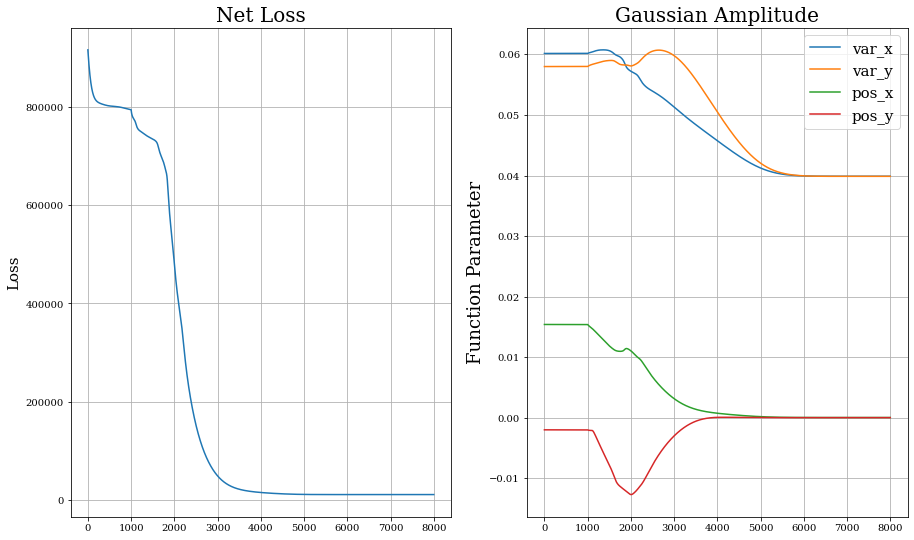

In [49]:
plt.figure(figsize=(15, 30))
plt.subplot(3, 2, 1)
stored_params_dict = pickle.load(open(filenames[0], "rb"))
plt.title("Net Loss", fontsize=20)
plt.plot(stored_params_dict["net loss"])
plt.grid()
plt.ylabel("Loss")
plt.subplot(3, 2, 2)
gauss_params = np.asarray(stored_params_dict["intensity.gauss_param"])[:, 0, :]
param_labels = ["var_x", "var_y", "pos_x", "pos_y"]
for param_i, p in enumerate(gauss_params.T):
    plt.plot(p, label="{}".format(param_labels[param_i]))
plt.grid()
plt.title("Gaussian Amplitude", fontsize=20)
plt.ylabel("Function Parameter", fontsize=18)
plt.legend(fontsize=15)
plt.subplot(3,2,3)

In [55]:
(recov_coeffs - aberr_coeffs.flatten()) * 1e9

Array([ 0.23391171,  0.00744978,  0.04033979, -0.02171838,  0.27364379,
        0.08658918,  0.1097036 , -0.42561591,  0.14752928, -0.20334095,
       -0.1756134 ,  0.03458148], dtype=float64)

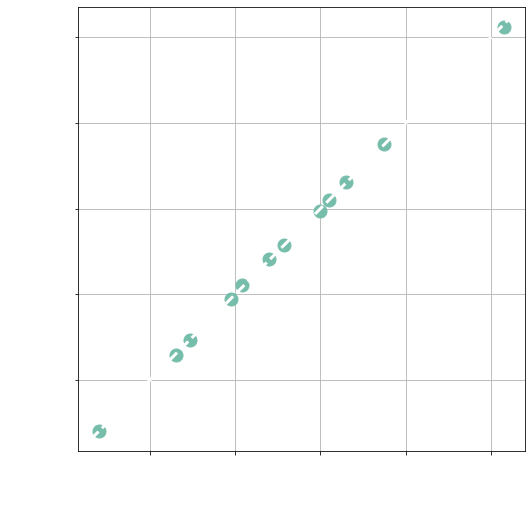

In [27]:
plt.figure(figsize=(8, 8))
recov_coeffs = current_config.aperture.coefficients
plt.plot(
    aberr_coeffs.flatten() * 1e9,
    recov_coeffs.flatten() * 1e9,
    "o",
    markersize=13,
    color="#77bdab",
)
plt.ylabel("Recovered Coefficients (nm)", fontsize=22, fontweight="bold", color="white")
plt.xlabel("Injected Coefficients (nm)", fontsize=22, fontweight="bold", color="white")
plt.xticks(fontsize=18, color="white")
plt.yticks(fontsize=18, color="white")
plt.gca().axline((0, 0), slope=1, linestyle="--", color="white", linewidth=3)

plt.grid()
plt.savefig("12.png", dpi=500, transparent=True)

<>:13: SyntaxWarning: invalid escape sequence '\c'
<>:13: SyntaxWarning: invalid escape sequence '\c'
/var/folders/2j/vdv93b7508qfh_tr2nx03dh80000gp/T/ipykernel_3177/1480001129.py:13: SyntaxWarning: invalid escape sequence '\c'
  plt.title("Z Score ($\chi^2$)", fontsize=18, fontweight="bold", color="white")


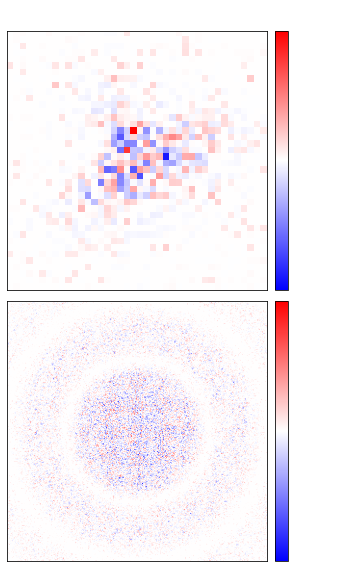

In [28]:
plt.figure(figsize=(11, 8))
plt.subplot(2, 1, 1)
current_config = config_models[0][0]
config_dict = config_stored_params[0]
for key in config_dict:
    if key in opt_params[0]:
        current_config = current_config.set(key, config_dict[key][-1, 0])
scaled_data = opt_datas[0][0]
poiss_err = scaled_data**0.5
zsc = (scaled_data - current_config.model()) / jnp.sqrt(poiss_err**2 + BFS_rn**2)
zsc = jnp.where(jnp.isnan(zsc), 0, zsc)
im = plt.imshow(zsc, norm=CenteredNorm(), cmap="bwr")
plt.title("Z Score ($\chi^2$)", fontsize=18, fontweight="bold", color="white")
plt.xticks([])
plt.yticks([])
cbar = plt.colorbar(im, pad=0.01)
cbar.ax.tick_params(
    labelsize=15,
    color="white",
    labelcolor="white",
)
for label in cbar.ax.get_yticklabels():
    label.set_fontweight("bold")
plt.subplot(2, 1, 2)
current_config = config_models[1][0]
config_dict = config_stored_params[1]
for key in config_dict:
    if key in opt_params[1]:
        current_config = current_config.set(key, config_dict[key][-1, 0])
scaled_data = opt_datas[1][0]
poiss_err = scaled_data**0.5
zsc = (scaled_data - current_config.model()) / jnp.sqrt(poiss_err**2 + BFS_rn**2)
zsc = jnp.where(jnp.isnan(zsc), 0, zsc)
im = plt.imshow(zsc, norm=CenteredNorm(), cmap="bwr")
plt.xticks([])
plt.yticks([])
cbar = plt.colorbar(im, pad=0.01)
cbar.set_label(" ", fontsize=15, fontweight="bold")
cbar.ax.tick_params(
    labelsize=15,
    color="white",
    labelcolor="white",
)
for label in cbar.ax.get_yticklabels():
    label.set_fontweight("bold")
plt.tight_layout()
plt.savefig("10.png", transparent=True)

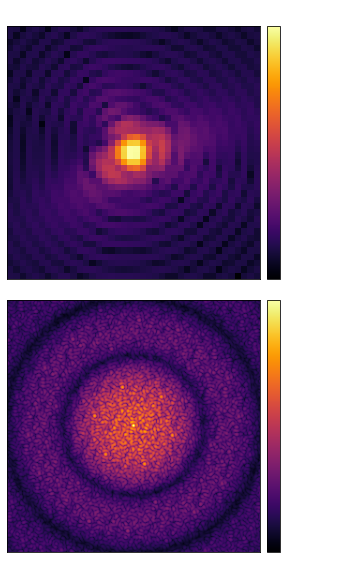

In [29]:
plt.figure(figsize=(11, 8))
plt.subplot(2, 1, 1)
current_config = config_models[0][0]
config_dict = config_stored_params[0]
for key in config_dict:
    if key in opt_params[0]:
        current_config = current_config.set(key, config_dict[key][-1, 0])
psf = current_config.model()
im = plt.imshow(psf, norm=PowerNorm(0.2))
plt.title("Final State", fontsize=18, fontweight="bold", color="white")
plt.xticks([])
plt.yticks([])
cbar = plt.colorbar(im, pad=0.01)
cbar.ax.tick_params(
    labelsize=15,
    color="white",
    labelcolor="white",
)
for label in cbar.ax.get_yticklabels():
    label.set_fontweight("bold")
plt.subplot(2, 1, 2)
current_config = config_models[1][0]
config_dict = config_stored_params[1]
for key in config_dict:
    if key in opt_params[1]:
        current_config = current_config.set(key, config_dict[key][-1, 0])
psf = current_config.model()
im = plt.imshow(psf, norm=PowerNorm(0.2))
plt.xticks([])
plt.yticks([])
cbar = plt.colorbar(im, pad=0.01)
cbar.set_label(" ", fontsize=15, fontweight="bold")
cbar.ax.tick_params(
    labelsize=15,
    color="white",
    labelcolor="white",
)
for label in cbar.ax.get_yticklabels():
    label.set_fontweight("bold")
plt.tight_layout()
plt.savefig("11.png", transparent=True)

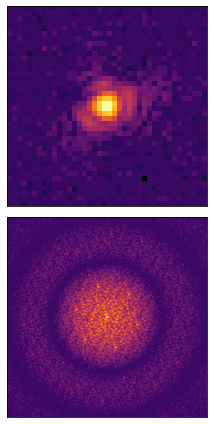

In [30]:
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.imshow(opt_datas[0][0], norm=PowerNorm(0.2))
plt.xticks([])
plt.yticks([])
plt.subplot(2, 1, 2)
plt.imshow(opt_datas[1][0], norm=PowerNorm(0.2))
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.savefig("1.png", transparent=True)

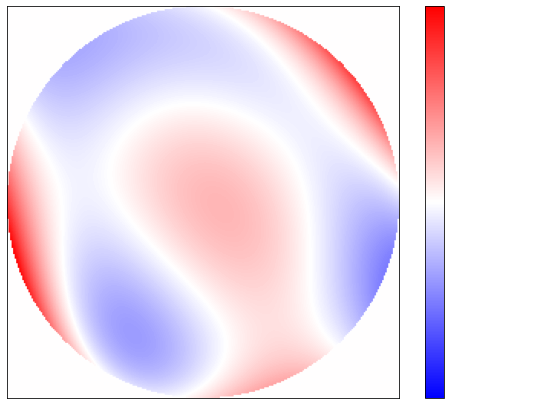

In [31]:
plt.figure(figsize=(8, 6))
im = plt.imshow(
    dummy_open_model.aperture.eval_basis() / red_laser_wl,
    cmap="bwr",
    norm=CenteredNorm(0),
)
cbar = plt.colorbar(label="OPD (waves)")
cbar.set_label(label="OPD (waves)", size=20, color="white", fontweight="bold")
cbar.ax.tick_params(
    labelsize=20,
    color="white",
    labelcolor="white",
)
for label in cbar.ax.get_yticklabels():
    label.set_fontweight("bold")
plt.tight_layout()
plt.xticks([])
plt.yticks([])
plt.savefig("2.png", transparent=True)

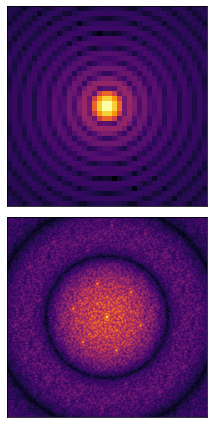

In [32]:
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.imshow(models[0][0].model(), norm=PowerNorm(0.2))
plt.xticks([])
plt.yticks([])
plt.subplot(2, 1, 2)
plt.imshow(models[1][0].model(), norm=PowerNorm(0.2))
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.savefig("3.png", transparent=True)

In [33]:
plt.rcParams["font.family"] = "sans-serif"

Text(0.5, 0, 'Epoch')

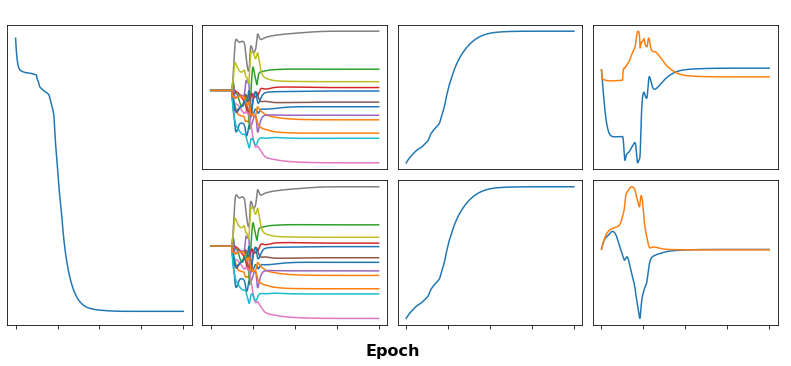

In [35]:
# layout = [["A", "A"], ["B", "C"], ["D", "E"], ["F", "G"]]
layout = [["A", "B", "D", "F"], ["A", "C", "E", "G"]]
# layout = [["B"], ["C"]]


fig, axes = plt.subplot_mosaic(layout, figsize=(11, 5))
stored_params_dict = pickle.load(open(filename, "rb"))
axes["A"].plot(stored_params_dict["net loss"])
# axes["A"].grid(True)
axes["A"].set_title("Net Loss", fontsize=16, fontweight="bold", color="white")
# axes["A"].set_xticks([])
axes["A"].set_yticks([])
axes["A"].tick_params(axis="x", labelsize=12, labelcolor="white")


config_dict = config_stored_params[0]
current_config = models[0][0]
coeffs_arr = np.asarray(config_dict["aperture.coefficients"])[:, 0, :]
for k in range(coeffs_arr.shape[-1]):
    label = "Coeff " + str(zernike_indicies[l])
    axes["B"].plot(coeffs_arr[:, k] * 1e9, label=label)
axes["B"].set_title(
    "Zernike Coefficients (nm)", fontsize=14, fontweight="bold", color="white"
)
axes["B"].set_xticks([])
axes["B"].set_yticks([])


plate_scale_arr = np.asarray(config_dict["psf_pixel_scale"])[:, 0]
axes["D"].plot(plate_scale_arr)
axes["D"].set_title(
    "Plate Scale (arcsec)", fontsize=14, fontweight="bold", color="white"
)
# axes["D"].grid()
axes["D"].set_xticks([])
axes["D"].set_yticks([])

pos = np.asarray(config_dict["source.position"])
Positions_x = pos[:, 0, 0] * 1e6
Positions_y = pos[:, 0, 1] * 1e6
axes["F"].plot(Positions_x, label="Position X - {}".format(config_labels[0]))
axes["F"].plot(Positions_y, label="Position Y - {}".format(config_labels[0]))
axes["F"].set_title("Source Position", fontsize=14, fontweight="bold", color="white")
axes["F"].set_xticks([])
axes["F"].set_yticks([])


config_dict = config_stored_params[1]
current_config = models[1][0]
coeffs_arr = np.asarray(config_dict["aperture.coefficients"])[:, 0, :]
for k in range(coeffs_arr.shape[-1]):
    label = "Coeff " + str(zernike_indicies[l])
    axes["C"].plot(coeffs_arr[:, k] * 1e9, label=label)
axes["C"].set_yticks([])
axes["C"].tick_params(axis="x", labelsize=12, labelcolor="white")


plate_scale_arr = np.asarray(config_dict["psf_pixel_scale"])[:, 0]
axes["E"].plot(plate_scale_arr)
# axes["E"].grid(True)
axes["E"].set_yticks([])
axes["E"].tick_params(axis="x", labelsize=12, labelcolor="white")


pos = np.asarray(config_dict["source.position"])
Positions_x = pos[:, 0, 0] * 1e6
Positions_y = pos[:, 0, 1] * 1e6
axes["G"].plot(Positions_x, label="Position X - {}".format(config_labels[0]))
axes["G"].plot(Positions_y, label="Position Y - {}".format(config_labels[0]))
axes["G"].set_yticks([])
axes["G"].tick_params(axis="x", labelsize=12, labelcolor="white")


plt.tight_layout()
# for key in config_dict:
#     if key in opt_params[config_i]:
#         current_config = current_config.set(key, config_dict[key][-1, 0])
# plt.imshow(
#     opd
#     * trans
#     / red_laser_wl
#     * current_config.front_ap.transmission(
#         coords=coords, pixel_scale=aperture_diameter / aperture_npix
#     ),
#     cmap="bwr",
#     norm=CenteredNorm(),
# )
fig.text(0.5, 0, "Epoch", ha="center", fontsize=16, fontweight="bold", color="black")

# plt.savefig("9.png", dpi=500, transparent=True)

In [203]:
# OPD correlation curve and residual psf plot

Add fisher info!

In [47]:
current_config = config_models[0][0]
config_dict = config_stored_params[0]
for key in config_dict:
    if key in opt_params[0]:
        current_config = current_config.set(key, config_dict[key][-1, 0])
model_open_pup = current_config
data_open_pup = opt_datas[0][0]

current_config = config_models[1][0]
config_dict = config_stored_params[1]
for key in config_dict:
    if key in opt_params[1]:
        current_config = current_config.set(key, config_dict[key][-1, 0])
model_sam18 = current_config
data_sam18 = opt_datas[1][0]

In [52]:
# individually
params = [
    "aperture.coefficients",
    # "psf_pixel_scale",
]
cov_open = zdx.self_covariance_matrix(
    pytree=model_open_pup,
    parameters=params,
    loglike_fn=zdx.bayes.poiss_loglike,
)
sig2_open = jnp.diag(cov_open)
print("Zernike precision open pup (nm): {}".format(jnp.sqrt(sig2_open) * 1e9))

cov_sam18 = zdx.self_covariance_matrix(
    pytree=model_sam18,
    parameters=params,
    loglike_fn=zdx.bayes.poiss_loglike,
)
sig2_sam18 = jnp.diag(cov_sam18)
print("Zernike precision sam18 (nm): {}".format(jnp.sqrt(sig2_sam18) * 1e9))

Zernike precision open pup (nm): [0.88163588 1.00524301 1.08542879 0.54620377 0.53155695 0.92104648
 0.9019016  0.59181565 0.65802191 0.63991952 0.85812844 0.83910634]
Zernike precision sam18 (nm): [0.21088488 0.10366717 0.15002905 0.1429752  0.17841714 0.12088525
 0.12739214 0.35318915 0.21878035 0.17012418 0.17645941 0.09435   ]


In [53]:
# combined
print("Zernike precision sam18 (nm): {}".format(jnp.sqrt(sig2_sam18 + sig2_open) * 1e9))

Zernike precision sam18 (nm): [0.90650662 1.01057429 1.09574832 0.56460647 0.56070087 0.92894557
 0.91085413 0.68919398 0.69343902 0.66214743 0.87608353 0.84439409]
